# XAI — MDI + SHAP — Random Forest

MDI + SHAP para el modelo **Random Forest** sobre las 4 herramientas (CIC, Nemea, Tstat, Tshark).

In [9]:
# ============================================================
# CELDA 0 — IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
import shap
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

shap.initjs()
print('✓ Imports OK')
print(f'  shap: {shap.__version__}')


✓ Imports OK
  shap: 0.49.1


In [10]:
# ============================================================
# CELDA 1 — CONFIGURACIÓN
# ============================================================

RUTA_BASE = Path('/home/miguel/Escritorio/TFM/TFM_Miguel/BaseDatos')

CLASES = [
    'BenignTraffic', 'DictionaryBruteForce', 'Recon',
    'Mirai', 'Spoofing', 'DoS', 'DDoS', 'Web'
]

HERRAMIENTAS = ['CIC', 'Nemea', 'Tstat', 'Tshark']

SEED = 42
TEST_SIZE = 0.2

COLS_ELIMINAR = {
    'CIC':    ['Label', 'Flow ID', 'Src IP', 'Dst IP', 'Src Port', 'Dst Port',
               'Timestamp', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags',
               'URG Flag Cnt', 'CWR Flag Count', 'ECE Flag Cnt',
               'Fwd Bytes/Bulk Avg', 'Fwd Bulk Rate Avg', 'Fwd Packet/Bulk Avg'],
    'Nemea':  ['LABEL', 'uint64 FLOW_ID', 'macaddr DST_MAC', 'macaddr SRC_MAC',
               'ipaddr SRC_IP', 'ipaddr DST_IP', 'uint16 SRC_PORT', 'uint16 DST_PORT',
               'time TIME_FIRST', 'time TIME_LAST',
               'time* DBI_BRST_TIME_START', 'time* DBI_BRST_TIME_STOP',
               'time* SBI_BRST_TIME_START', 'time* SBI_BRST_TIME_STOP'] +
              [f'time_PPI_PKT_TIMES_{i}' for i in range(30)],
    'Tstat':  ['etiqueta', 'fqdn', 'c_tls_SNI', 's_tls_SCN', 'c_npnalpn', 's_npnalpn',
               'c_tls_sesid', 'dns_rslv', 'last', 'c_first', 's_first', 'c_last', 's_last',
               'c_first_ack', 's_first_ack', 'c_last_handshakeT', 's_last_handshakeT',
               'c_appdataT', 's_appdataT', 'req_tm', 'res_tm', 's_first_abs',
               'c_ip', 's_ip', 'c_port', 's_port', 'first', 'c_first_abs'],
    'Tshark': ['category', 'src_ip', 'dst_ip', 'src_port', 'dst_port', 'start_epoch'],
}

TOP_N = 15
SHAP_SAMPLE = 500

GUARDAR_FIGURAS = True
RUTA_FIGURAS = Path('/home/miguel/Escritorio/TFM/TFM_Miguel/Figuras/MDI')
RUTA_FIGURAS.mkdir(parents=True, exist_ok=True)

print('✓ Configuración cargada')
print(f'  Base de datos: {RUTA_BASE}')
print(f'  Existe:        {RUTA_BASE.exists()}')


✓ Configuración cargada
  Base de datos: /home/miguel/Escritorio/TFM/TFM_Miguel/BaseDatos
  Existe:        True


In [11]:
# ============================================================
# CELDA 2 — FUNCIÓN DE CARGA Y LIMPIEZA
# ============================================================

def cargar_herramienta(herramienta):
    dfs = []
    for clase in CLASES:
        ruta = RUTA_BASE / clase / f'{herramienta}.csv'
        if not ruta.exists():
            print(f'  ⚠ No encontrado: {ruta}')
            continue
        df_tmp = pd.read_csv(ruta, low_memory=False)
        df_tmp['Label_Modelo'] = clase
        dfs.append(df_tmp)

    df = pd.concat(dfs, ignore_index=True)

    cols_por_clase = [set(pd.read_csv(RUTA_BASE / c / f'{herramienta}.csv',
                                      nrows=0, low_memory=False).columns)
                      for c in CLASES
                      if (RUTA_BASE / c / f'{herramienta}.csv').exists()]
    cols_comunes = set.intersection(*cols_por_clase) if cols_por_clase else set(df.columns)
    df = df[[c for c in df.columns if c in cols_comunes or c == 'Label_Modelo']]

    cols_drop = [c for c in COLS_ELIMINAR.get(herramienta, []) if c in df.columns]
    df = df.drop(columns=cols_drop)

    if herramienta == 'Nemea':
        quic_cols = [c for c in df.columns if 'QUIC' in c.upper()]
        df = df.drop(columns=quic_cols)

    y = df['Label_Modelo']
    X = df.drop(columns=['Label_Modelo'])

    # Eliminar columnas cuyo contenido sea listas serializadas como string
    cols_lista = [c for c in X.columns
                  if X[c].dtype == object and X[c].dropna().astype(str).str.startswith('[').any()]
    if cols_lista:
        print(f'  ⚠ Columnas-lista eliminadas: {cols_lista}')
        X = X.drop(columns=cols_lista)

    for col in X.select_dtypes(include='object').columns:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))

    ctes = [c for c in X.columns if X[c].nunique() <= 1]
    X = X.drop(columns=ctes)

    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.fillna(0)
    # Forzar todo a float64 (evita strings de notación científica que rompan SHAP)
    X = X.apply(pd.to_numeric, errors='coerce').fillna(0)

    feature_names = list(X.columns)
    print(f'[{herramienta}] Shape X: {X.shape} | Clases: {y.nunique()}')
    if ctes:
        print(f'  Constantes eliminadas: {len(ctes)}')
    return X, y, feature_names

print('✓ Función de carga definida')


✓ Función de carga definida


In [12]:
# ============================================================
# CELDA NUEVA B — FUNCIÓN analizar_modelo ACTUALIZADA
# Sustituye la CELDA 3 original. Guarda adicionalmente:
#   - 'shap_values_raw': shap_values SIN valor absoluto
#   - 'X_shap_raw':      las filas usadas para SHAP
#   - 'feature_names':   lista de nombres de features
# El resto del comportamiento es idéntico al original.
# ============================================================

def analizar_modelo(nombre_modelo, modelo_cls, kwargs_modelo, herramienta, X, y, feature_names):
    print(f'\n  [{herramienta}] Entrenando {nombre_modelo}...')

    le_y = LabelEncoder()
    y_enc = le_y.fit_transform(y)

    X_train, X_test, y_train, y_test = train_test_split(
        X.values, y_enc, test_size=TEST_SIZE, random_state=SEED, stratify=y_enc
    )

    modelo = modelo_cls(**kwargs_modelo)
    modelo.fit(X_train, y_train)
    f1 = f1_score(y_test, modelo.predict(X_test), average='macro')
    print(f'  [{herramienta}] F1 macro (test): {f1:.4f}')

    # ── MDI ─────────────────────────────────────────────────
    if hasattr(modelo, 'feature_importances_'):
        mdi = pd.Series(modelo.feature_importances_, index=feature_names)
        mdi_top = mdi.nlargest(TOP_N)
        fig, ax = plt.subplots(figsize=(8, 6))
        mdi_top.sort_values().plot(kind='barh', ax=ax, color='steelblue')
        ax.set_title(f'MDI Top-{TOP_N} — {nombre_modelo} / {herramienta}', fontsize=12)
        ax.set_xlabel('Importancia (MDI)', fontsize=11)
        ax.tick_params(axis='y', labelsize=13)
        ax.tick_params(axis='x', labelsize=13)
        plt.tight_layout()
        if GUARDAR_FIGURAS:
            fig.savefig(RUTA_FIGURAS / f'MDI_{nombre_modelo}_{herramienta}.pdf', dpi=150)
        plt.show()
        plt.close()
    else:
        mdi_top = None

    # ── SHAP ────────────────────────────────────────────────
    print(f'  [{herramienta}] Calculando SHAP...')
    X_shap = X_test[:SHAP_SAMPLE]

    shap_values = None
    try:
        explainer = shap.TreeExplainer(modelo)
        shap_values = explainer.shap_values(X_shap)
        print(f'  [{herramienta}] SHAP OK (TreeExplainer estándar)')
    except Exception as e1:
        print(f'  ⚠ TreeExplainer estándar falló: {e1}')
        try:
            explainer = shap.TreeExplainer(modelo, model_output='raw')
            shap_values = explainer.shap_values(X_shap)
            print(f'  [{herramienta}] SHAP OK (model_output=raw)')
        except Exception as e2:
            print(f'  ⚠ model_output=raw falló: {e2}')
            try:
                explainer = shap.Explainer(modelo, X_shap)
                sv = explainer(X_shap)
                shap_values = sv.values
                print(f'  [{herramienta}] SHAP OK (shap.Explainer genérico)')
            except Exception as e3:
                print(f'  ✗ Todos los intentos SHAP fallaron: {e3}')
                shap_values = None

    if shap_values is None:
        print(f'  [{herramienta}] Saltando plots SHAP.')
        importancia_shap = pd.Series(dtype=float)
    else:
        # ── Bar plot (|SHAP|, igual que antes) ──────────────
        if isinstance(shap_values, list):
            shap_abs_mean = np.mean([np.abs(sv) for sv in shap_values], axis=0)
        else:
            if shap_values.ndim == 3:
                shap_abs_mean = np.mean(np.abs(shap_values), axis=2)
            else:
                shap_abs_mean = np.abs(shap_values)

        fig, ax = plt.subplots(figsize=(8, 6))
        shap.summary_plot(
            shap_abs_mean, X_shap,
            feature_names=feature_names,
            max_display=TOP_N,
            plot_type='bar',
            show=False
        )
        plt.title(f'SHAP Top-{TOP_N} — {nombre_modelo} / {herramienta}', fontsize=12)
        plt.tight_layout()
        if GUARDAR_FIGURAS:
            fig.savefig(RUTA_FIGURAS / f'SHAP_bar_{nombre_modelo}_{herramienta}.pdf', dpi=150)
        plt.show()
        plt.close()

        importancia_shap = pd.Series(
            shap_abs_mean.mean(axis=0), index=feature_names
        ).nlargest(15)

    return {
        'modelo':           nombre_modelo,
        'herramienta':      herramienta,
        'f1':               f1,
        'mdi_top':          mdi_top,
        'shap_top':         importancia_shap,
        # ── NUEVO: guardamos los valores crudos para beeswarm y comparación ──
        'shap_values_raw':  shap_values,
        'X_shap_raw':       X_shap,
        'feature_names':    feature_names,
    }

print('✓ analizar_modelo actualizada (guarda shap_values_raw y X_shap_raw)')

✓ analizar_modelo actualizada (guarda shap_values_raw y X_shap_raw)



  RF — CIC
[CIC] Shape X: (27848, 69) | Clases: 8
  Constantes eliminadas: 1

  [CIC] Entrenando RF...
  [CIC] F1 macro (test): 0.7355


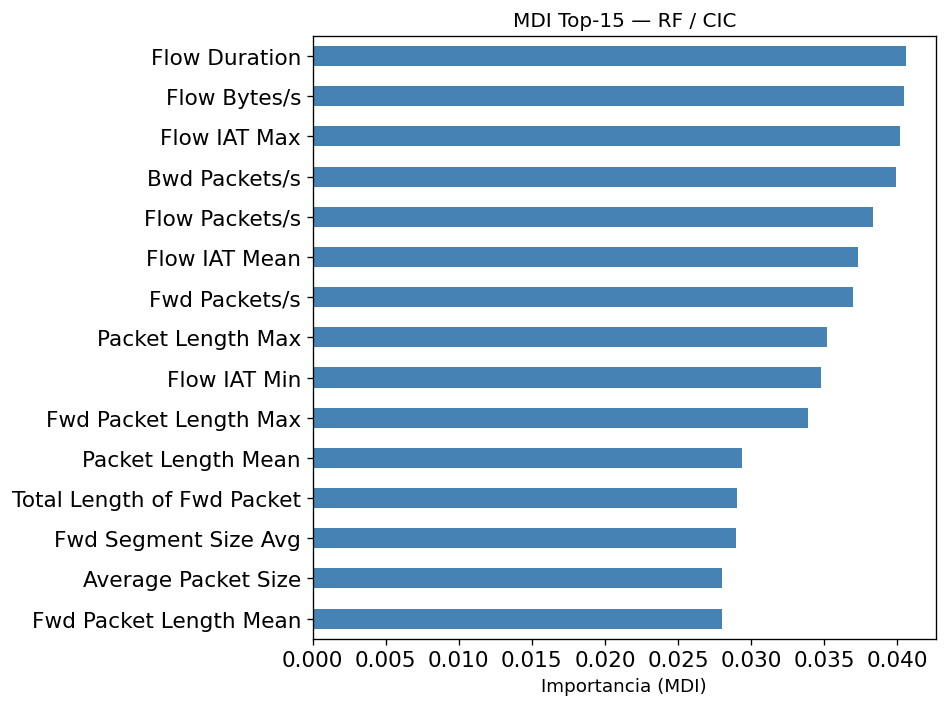

  [CIC] Calculando SHAP...
  [CIC] SHAP OK (TreeExplainer estándar)


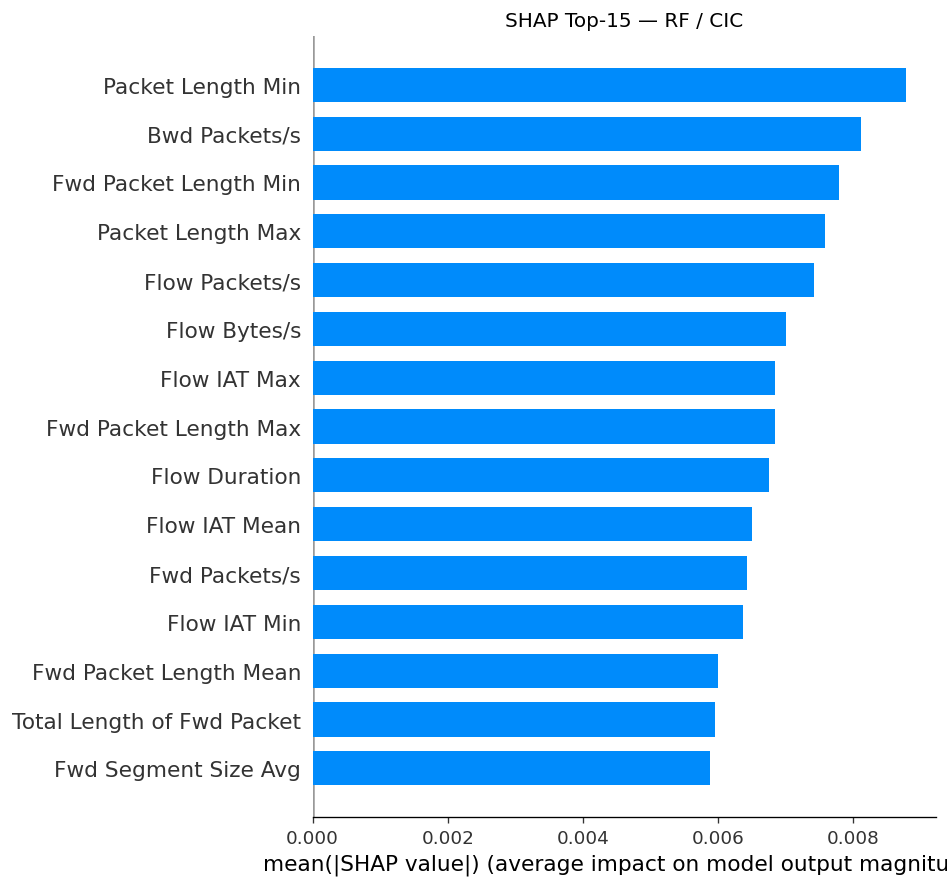


  RF — Nemea
  ⚠ Columnas-lista eliminadas: ['uint32* DBI_BRST_BYTES', 'uint32* DBI_BRST_PACKETS', 'uint32* SBI_BRST_BYTES', 'uint32* SBI_BRST_PACKETS']
[Nemea] Shape X: (27848, 144) | Clases: 8
  Constantes eliminadas: 1

  [Nemea] Entrenando RF...
  [Nemea] F1 macro (test): 0.5886


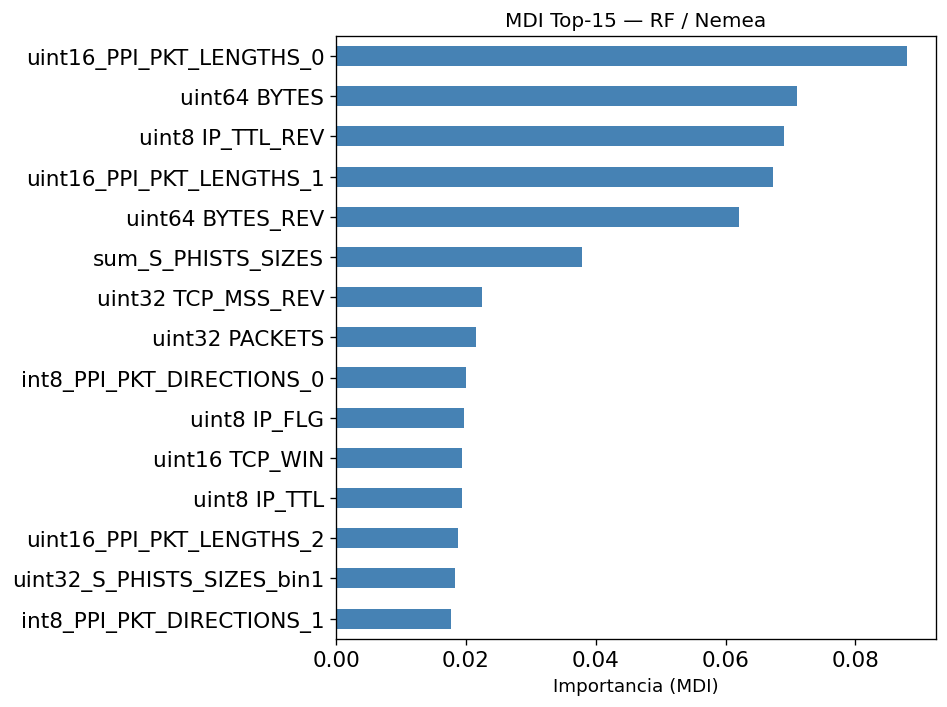

  [Nemea] Calculando SHAP...
  [Nemea] SHAP OK (TreeExplainer estándar)


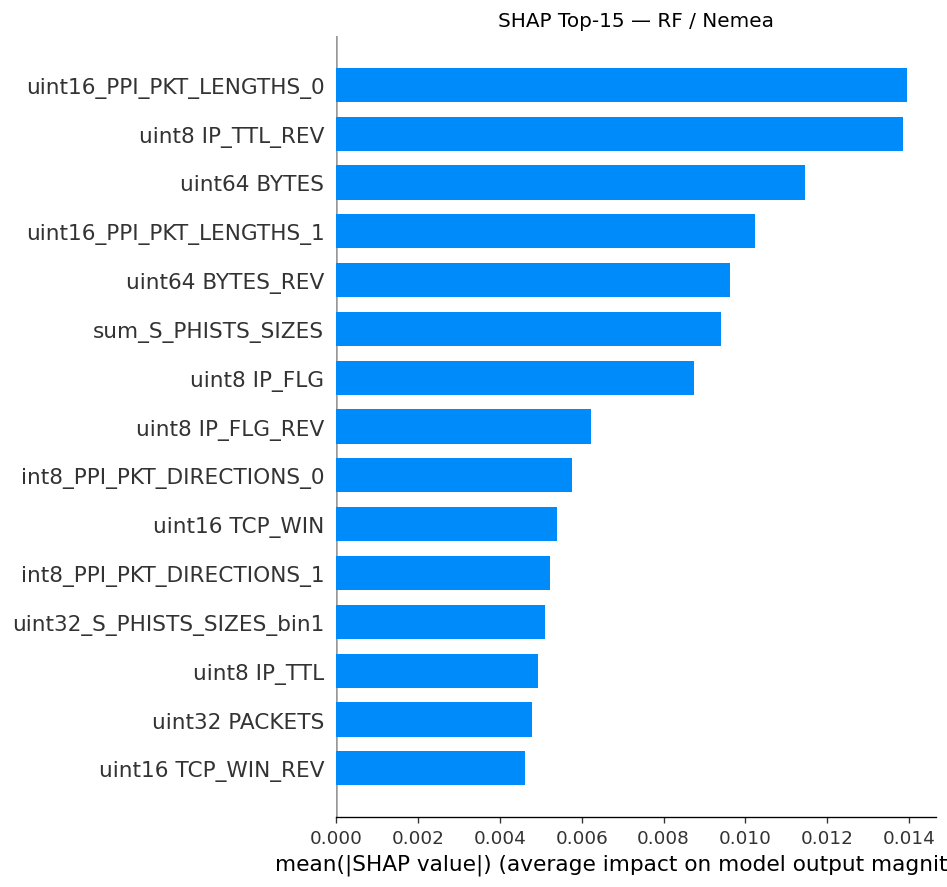


  RF — Tstat
[Tstat] Shape X: (27848, 96) | Clases: 8
  Constantes eliminadas: 14

  [Tstat] Entrenando RF...
  [Tstat] F1 macro (test): 0.6317


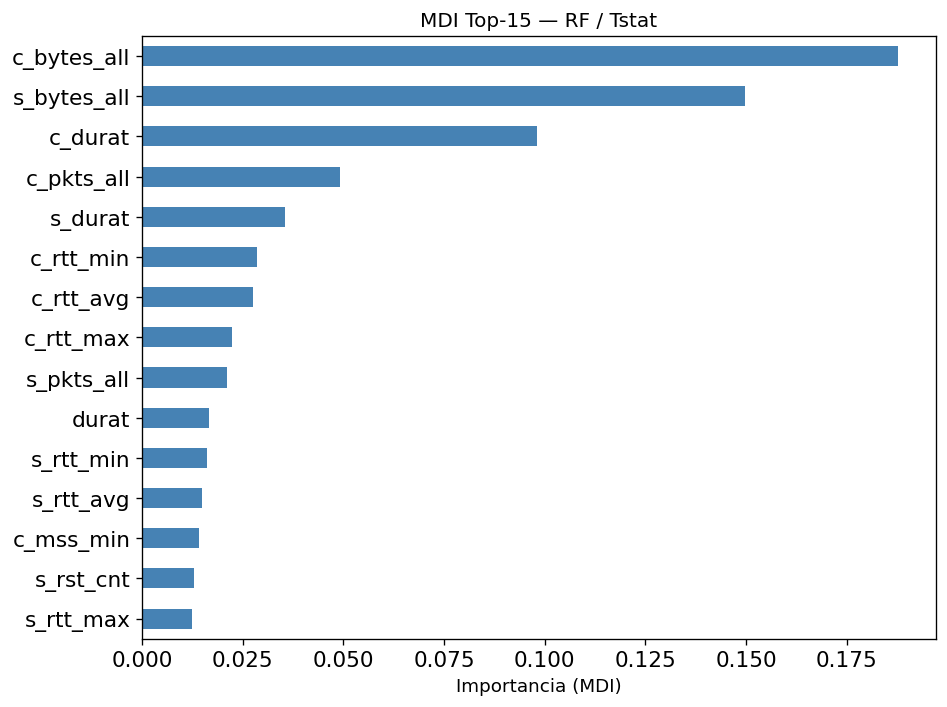

  [Tstat] Calculando SHAP...
  [Tstat] SHAP OK (TreeExplainer estándar)


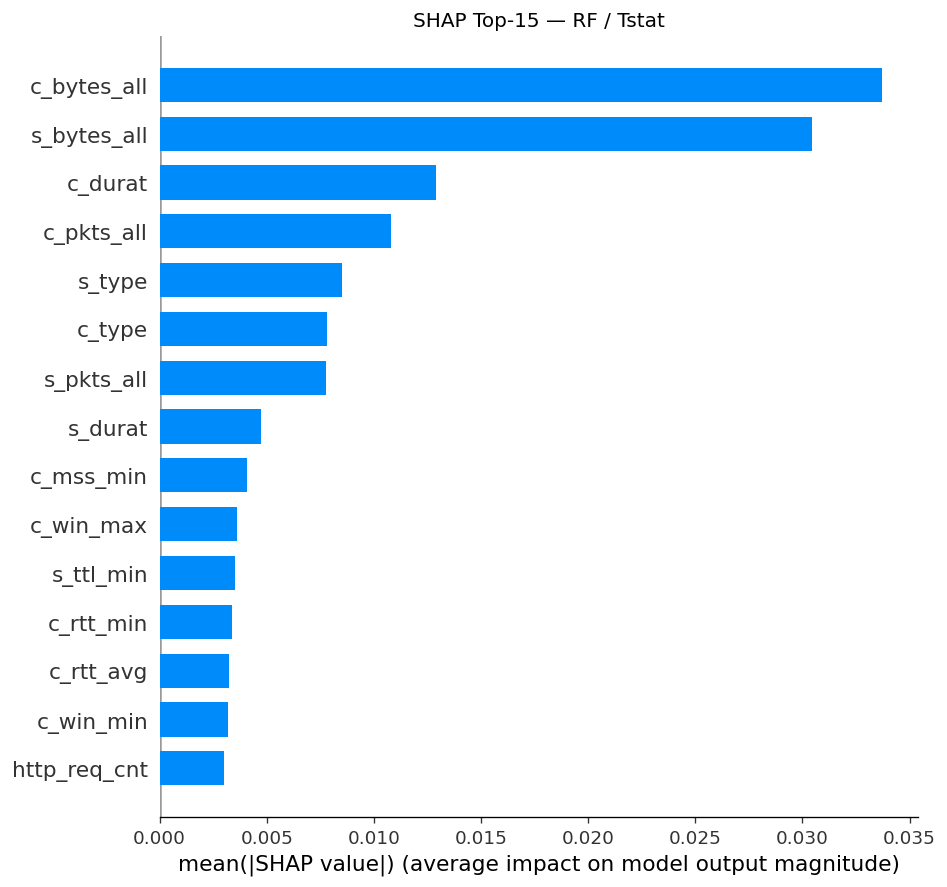


  RF — Tshark
[Tshark] Shape X: (27848, 50) | Clases: 8
  Constantes eliminadas: 7

  [Tshark] Entrenando RF...
  [Tshark] F1 macro (test): 0.7558


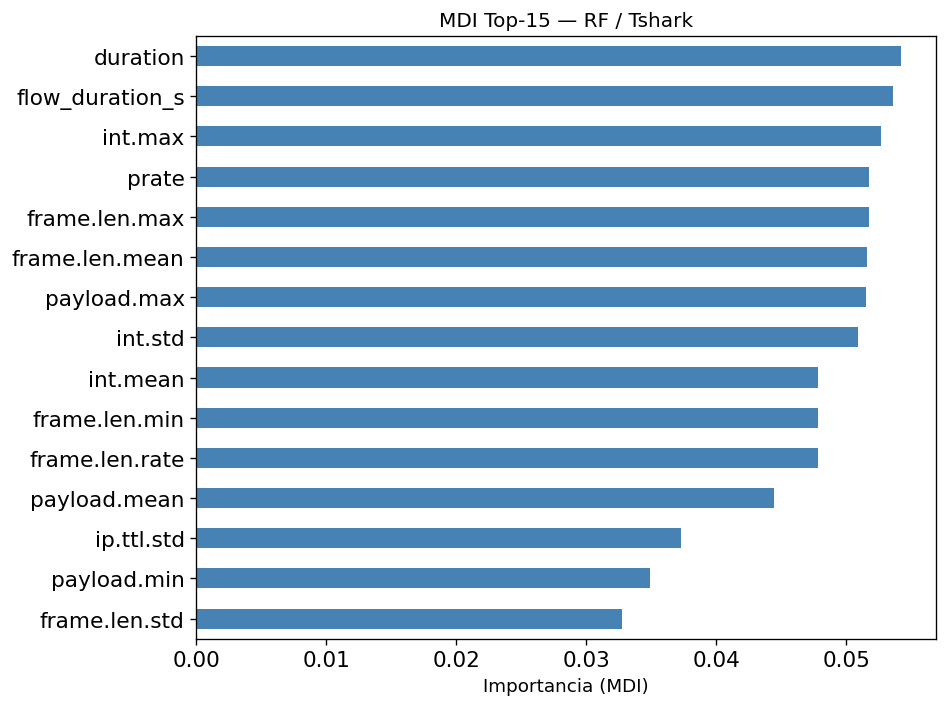

  [Tshark] Calculando SHAP...
  [Tshark] SHAP OK (TreeExplainer estándar)


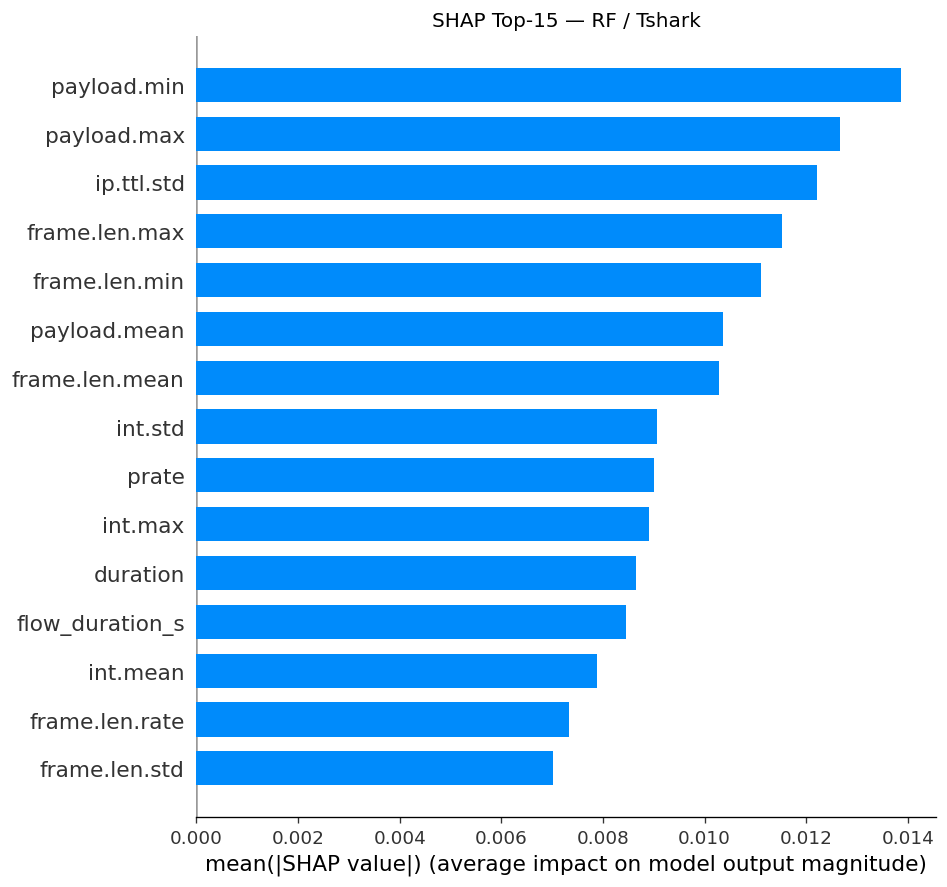


✓ Random Forest completado


In [13]:
# ============================================================
# CELDA 4 — RANDOM FOREST
# Mejores hiperparámetros Optuna (100 trials)
# ============================================================

MEJORES_RF = {
    'CIC':    dict(n_estimators=599, max_depth=20, max_features='log2', min_samples_split=10, min_samples_leaf=2),
    'Nemea':  dict(n_estimators=408, max_depth=22, max_features='sqrt', min_samples_split=5,  min_samples_leaf=1),
    'Tstat':  dict(n_estimators=361, max_depth=29, max_features='sqrt', min_samples_split=8,  min_samples_leaf=1),
    'Tshark': dict(n_estimators=385, max_depth=22, max_features='sqrt', min_samples_split=11, min_samples_leaf=1),
}

resultados_rf = []

for herramienta in HERRAMIENTAS:
    sep = '='*55; print(f'\n{sep}')
    print(f'  RF — {herramienta}')
    print(sep)
    X, y, feature_names = cargar_herramienta(herramienta)
    kwargs = {**MEJORES_RF[herramienta], 'random_state': SEED, 'n_jobs': 4}
    res = analizar_modelo('RF', RandomForestClassifier, kwargs, herramienta, X, y, feature_names)
    resultados_rf.append(res)

print('\n✓ Random Forest completado')


In [14]:
# ============================================================
# CELDA 5 — TABLA RESUMEN (RF)
# ============================================================

print('\n' + '='*70)
print('  RESUMEN TOP-5 SHAP — Random Forest × 4 herramientas')
print('='*70)

for res in resultados_rf:
    top15 = res['shap_top'].head(15)
    features_str = ', '.join(top15.index.tolist())
    print(f'  {res["herramienta"]:8s} (F1={res["f1"]:.4f}): {features_str}')

filas = []
for res in resultados_rf:
    for rank, (feat, val) in enumerate(res['shap_top'].items(), 1):
        filas.append({
            'Modelo': res['modelo'],
            'Herramienta': res['herramienta'],
            'F1 macro': round(res['f1'], 4),
            'Rank SHAP': rank,
            'Feature': feat,
            'SHAP medio': round(float(val), 6)
        })

df_resumen_rf = pd.DataFrame(filas)
ruta_csv = RUTA_FIGURAS / 'shap_resumen_RF.csv'
df_resumen_rf.to_csv(ruta_csv, index=False)
print(f'\n✓ Resumen guardado en {ruta_csv}')
df_resumen_rf[df_resumen_rf['Rank SHAP'] <= 15]



  RESUMEN TOP-5 SHAP — Random Forest × 4 herramientas
  CIC      (F1=0.7355): Packet Length Min, Bwd Packets/s, Fwd Packet Length Min, Packet Length Max, Flow Packets/s, Flow Bytes/s, Flow IAT Max, Fwd Packet Length Max, Flow Duration, Flow IAT Mean, Fwd Packets/s, Flow IAT Min, Fwd Packet Length Mean, Total Length of Fwd Packet, Fwd Segment Size Avg
  Nemea    (F1=0.5886): uint16_PPI_PKT_LENGTHS_0, uint8 IP_TTL_REV, uint64 BYTES, uint16_PPI_PKT_LENGTHS_1, uint64 BYTES_REV, sum_S_PHISTS_SIZES, uint8 IP_FLG, uint8 IP_FLG_REV, int8_PPI_PKT_DIRECTIONS_0, uint16 TCP_WIN, int8_PPI_PKT_DIRECTIONS_1, uint32_S_PHISTS_SIZES_bin1, uint8 IP_TTL, uint32 PACKETS, uint16 TCP_WIN_REV
  Tstat    (F1=0.6317): c_bytes_all, s_bytes_all, c_durat, c_pkts_all, s_type, c_type, s_pkts_all, s_durat, c_mss_min, c_win_max, s_ttl_min, c_rtt_min, c_rtt_avg, c_win_min, http_req_cnt
  Tshark   (F1=0.7558): payload.min, payload.max, ip.ttl.std, frame.len.max, frame.len.min, payload.mean, frame.len.mean, int.std, pra

,Modelo,Herramienta,F1 macro,Rank SHAP,Feature,SHAP medio
0,RF,CIC,0.7355,1,Packet Length Min,0.008791
1,RF,CIC,0.7355,2,Bwd Packets/s,0.008126
2,RF,CIC,0.7355,3,Fwd Packet Length Min,0.007788
3,RF,CIC,0.7355,4,Packet Length Max,0.007594
4,RF,CIC,0.7355,5,Flow Packets/s,0.007428
5,RF,CIC,0.7355,6,Flow Bytes/s,0.007013
6,RF,CIC,0.7355,7,Flow IAT Max,0.006851
7,RF,CIC,0.7355,8,Fwd Packet Length Max,0.006840
8,RF,CIC,0.7355,9,Flow Duration,0.006753
9,RF,CIC,0.7355,10,Flow IAT Mean,0.006510



[CIC] Beeswarm con signo — RF
  Rango SHAP: [-0.000000000000000202, 0.000000000000000217]
  Features con valores negativos: 39 de 69


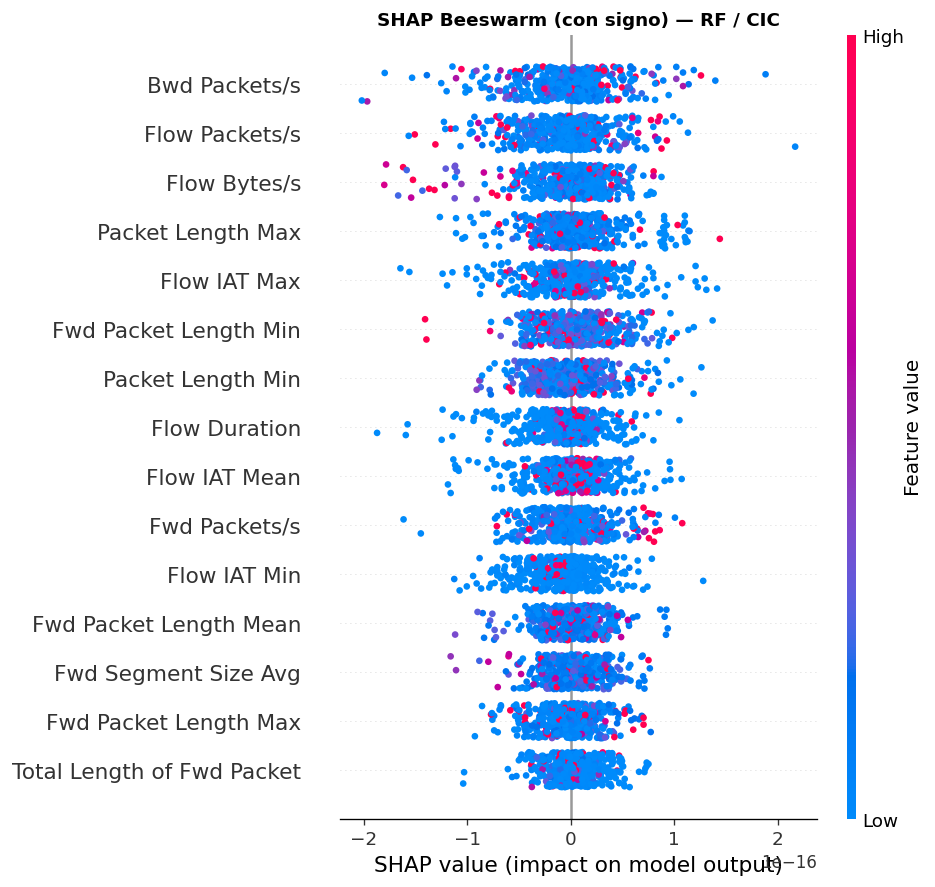

  Top contrafácticos (SHAP negativo en clase más negativa):
    Flow IAT Min                              -0.000000000000000009
    Flow Duration                             -0.000000000000000006
    Flow Packets/s                            -0.000000000000000005
    Packet Length Min                         -0.000000000000000003
    Fwd IAT Min                               -0.000000000000000003

[Nemea] Beeswarm con signo — RF
  Rango SHAP: [-0.000000000000000533, 0.000000000000000378]
  Features con valores negativos: 64 de 144


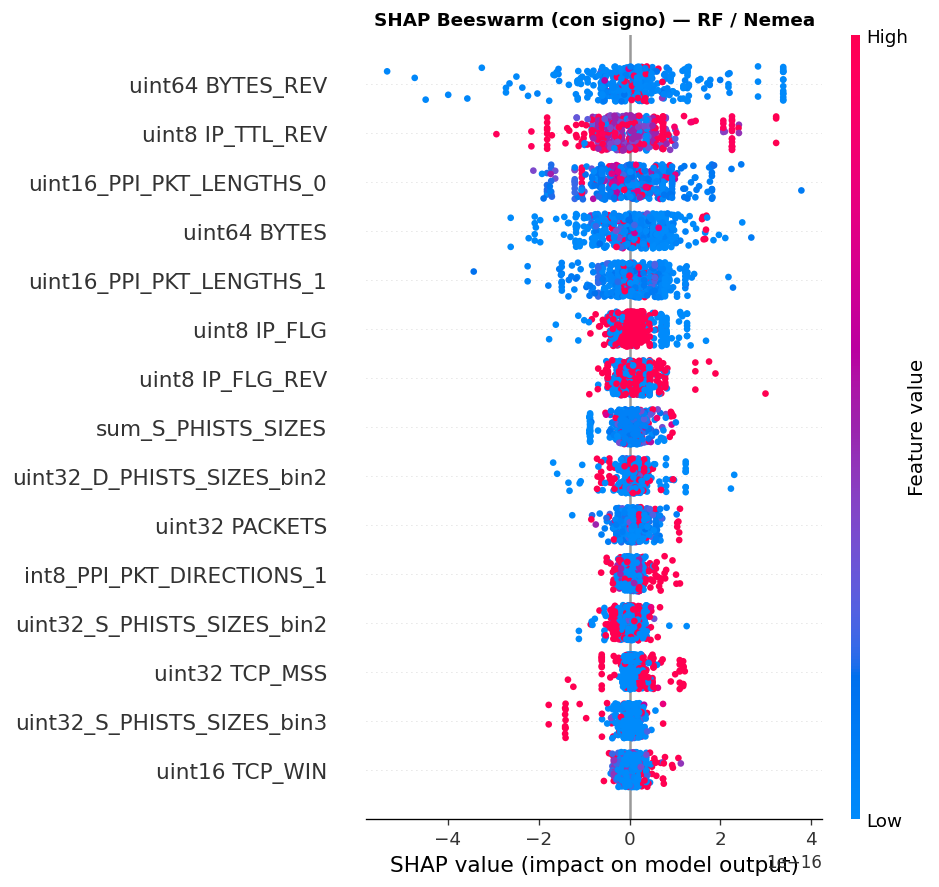

  Top contrafácticos (SHAP negativo en clase más negativa):
    sum_S_PHISTS_IPT                          -0.000000000000000003
    uint32_S_PHISTS_SIZES_bin3                -0.000000000000000002
    uint32_D_PHISTS_IPT_bin6                  -0.000000000000000002
    uint16 TCP_WIN_REV                        -0.000000000000000002
    uint8 TCP_FLAGS_REV                       -0.000000000000000002

[Tstat] Beeswarm con signo — RF
  Rango SHAP: [-0.000000000000002725, 0.000000000000007417]
  Features con valores negativos: 62 de 96


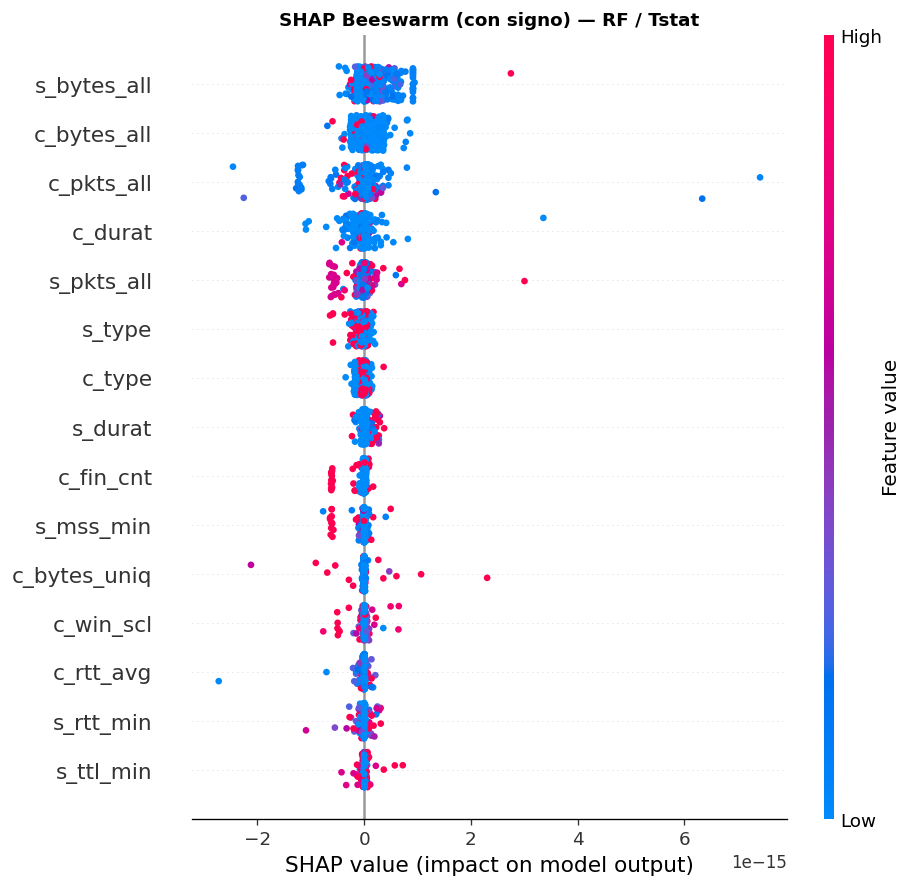

  Top contrafácticos (SHAP negativo en clase más negativa):
    s_type                                    -0.000000000000000034
    c_durat                                   -0.000000000000000020
    s_mss_min                                 -0.000000000000000018
    c_fin_cnt                                 -0.000000000000000017
    s_pkts_all                                -0.000000000000000015

[Tshark] Beeswarm con signo — RF
  Rango SHAP: [-0.000000000000000628, 0.000000000000000334]
  Features con valores negativos: 29 de 50


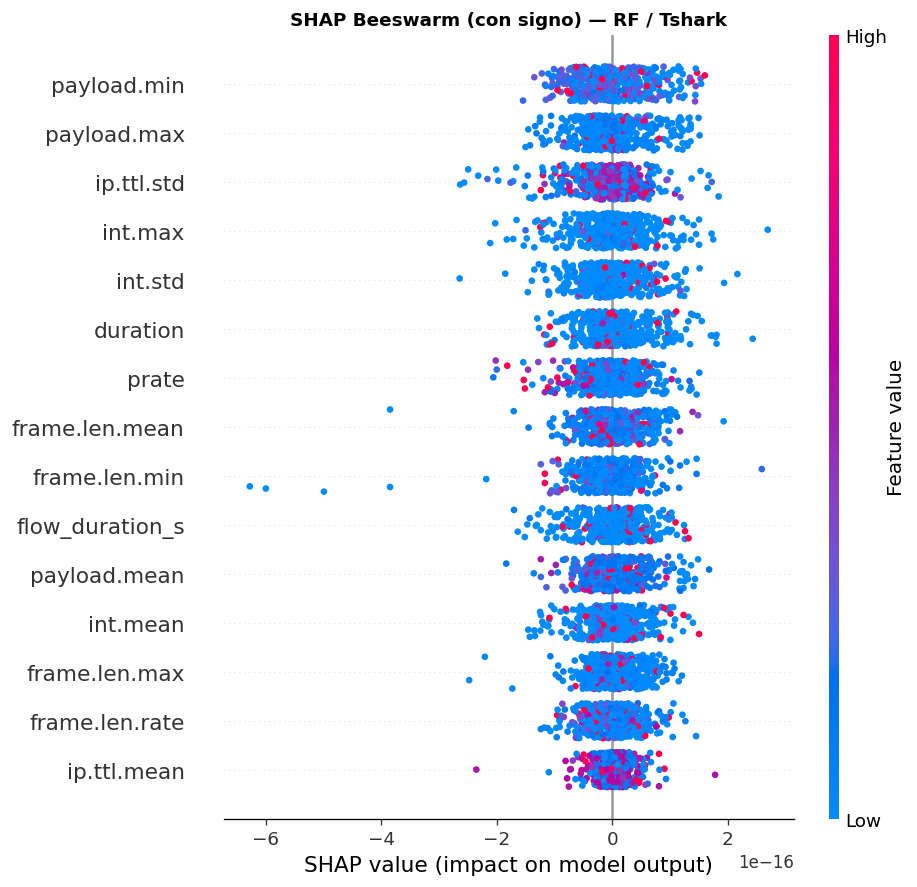

  Top contrafácticos (SHAP negativo en clase más negativa):
    frame.len.min                             -0.000000000000000007
    ip.ttl.std                                -0.000000000000000005
    payload.max                               -0.000000000000000004
    int.std                                   -0.000000000000000004
    ip.ttl.min                                -0.000000000000000003


In [15]:
# ============================================================
# CELDA NUEVA A — BEESWARM CON SIGNO (contrafácticos)
# Añadir al final del notebook, DESPUÉS de haber ejecutado
# el bucle principal (resultados_lgbm / resultados_rf / resultados_xgb)
#
# A diferencia del bar plot (que usa |SHAP|), el beeswarm
# conserva el signo: valores negativos = la feature ALEJA
# la predicción de esa clase (contrafácticos).
# El color indica el valor de la feature (rojo=alto, azul=bajo).
# ============================================================

def beeswarm_con_signo(resultados, nombre_modelo):
    for res in resultados:
        herramienta = res['herramienta']
        shap_values = res.get('shap_values_raw')
        X_shap      = res.get('X_shap_raw')
        feature_names = res.get('feature_names')

        if shap_values is None:
            print(f'[{herramienta}] Sin shap_values_raw — saltando beeswarm.')
            continue

        # RF devuelve lista de 8 arrays (uno por clase): NO se puede promediar
        # porque los signos se cancelan. Se pasa la lista directamente a
        # summary_plot, que muestra el impacto global con signo correctamente.
        if isinstance(shap_values, list):
            # Usamos la clase con mayor varianza SHAP para el rango informativo
            sv_para_rango = np.concatenate(shap_values, axis=0)
            print(f'\n[{herramienta}] Beeswarm con signo — {nombre_modelo}')
            print(f'  Rango SHAP: [{sv_para_rango.min():.18f}, {sv_para_rango.max():.18f}]')
            n_neg = sum(1 for sv in shap_values if sv.mean() < 0)
            print(f'  Clases con contribución negativa media: {n_neg} de {len(shap_values)}')

            fig, ax = plt.subplots(figsize=(9, 7))
            shap.summary_plot(
                shap_values,   # lista completa — shap sabe interpretarla
                X_shap,
                feature_names=feature_names,
                max_display=TOP_N,
                plot_type='dot',
                show=False,
                color_bar=True,
            )
        elif shap_values.ndim == 3:
            sv_signed = shap_values.mean(axis=2)
            print(f'\n[{herramienta}] Beeswarm con signo — {nombre_modelo}')
            print(f'  Rango SHAP: [{sv_signed.min():.18f}, {sv_signed.max():.18f}]')
            print(f'  Features con valores negativos: '
                  f'{(sv_signed.mean(axis=0) < 0).sum()} de {sv_signed.shape[1]}')
            fig, ax = plt.subplots(figsize=(9, 7))
            shap.summary_plot(
                sv_signed, X_shap,
                feature_names=feature_names,
                max_display=TOP_N,
                plot_type='dot',
                show=False,
                color_bar=True,
            )
        else:
            sv_signed = shap_values
            fig, ax = plt.subplots(figsize=(9, 7))
            shap.summary_plot(
                sv_signed, X_shap,
                feature_names=feature_names,
                max_display=TOP_N,
                plot_type='dot',
                show=False,
                color_bar=True,
            )

        plt.title(f'SHAP Beeswarm (con signo) — {nombre_modelo} / {herramienta}',
                  fontsize=11, fontweight='bold')
        plt.tight_layout()
        if GUARDAR_FIGURAS:
            fig.savefig(RUTA_FIGURAS / f'SHAP_beeswarm_{nombre_modelo}_{herramienta}.pdf', dpi=150)
        plt.show()
        plt.close()

        # Contrafácticos: clase con menor SHAP medio
        if isinstance(shap_values, list):
            medias_por_clase = [sv.mean() for sv in shap_values]
            clase_min = np.argmin(medias_por_clase)
            sv_neg = pd.Series(shap_values[clase_min].mean(axis=0), index=feature_names)
            negativos = sv_neg[sv_neg < 0].sort_values()
        else:
            sv_mean = (shap_values.mean(axis=2) if shap_values.ndim == 3 else shap_values).mean(axis=0)
            negativos = pd.Series(sv_mean, index=feature_names)
            negativos = negativos[negativos < 0].sort_values()

        if len(negativos):
            print(f'  Top contrafácticos (SHAP negativo en clase más negativa):')
            for feat, val in negativos.head(5).items():
                print(f'    {feat:40s}  {val:.18f}')
        else:
            print(f'  No hay features con SHAP negativo.')


# Cambia aquí el nombre según el notebook que estés ejecutando:
#   resultados_lgbm   → LightGBM
#   resultados_rf     → RF
#   resultados_xgb    → XGBoost
beeswarm_con_signo(resultados_rf, 'RF')


  COMPARACIÓN MDI vs SHAP — RF

  [CIC]
  Rank  Feature MDI                          Feature SHAP                       
  ----  -----------------------------------  -----------------------------------
     1  Flow Duration                        Packet Length Min                     
     2  Flow Bytes/s                         Bwd Packets/s                         
     3  Flow IAT Max                         Fwd Packet Length Min                 
     4  Bwd Packets/s                        Packet Length Max                     
     5  Flow Packets/s                       Flow Packets/s                       ✓
     6  Flow IAT Mean                        Flow Bytes/s                          
     7  Fwd Packets/s                        Flow IAT Max                          
     8  Packet Length Max                    Fwd Packet Length Max                 
     9  Flow IAT Min                         Flow Duration                         
    10  Fwd Packet Length Max            

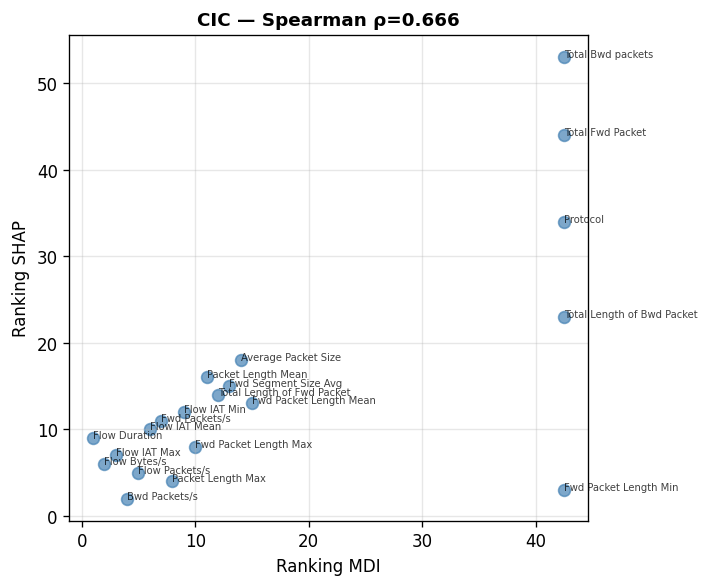


  [Nemea]
  Rank  Feature MDI                          Feature SHAP                       
  ----  -----------------------------------  -----------------------------------
     1  uint16_PPI_PKT_LENGTHS_0             uint16_PPI_PKT_LENGTHS_0             ✓
     2  uint64 BYTES                         uint8 IP_TTL_REV                      
     3  uint8 IP_TTL_REV                     uint64 BYTES                          
     4  uint16_PPI_PKT_LENGTHS_1             uint16_PPI_PKT_LENGTHS_1             ✓
     5  uint64 BYTES_REV                     uint64 BYTES_REV                     ✓
     6  sum_S_PHISTS_SIZES                   sum_S_PHISTS_SIZES                   ✓
     7  uint32 TCP_MSS_REV                   uint8 IP_FLG                          
     8  uint32 PACKETS                       uint8 IP_FLG_REV                      
     9  int8_PPI_PKT_DIRECTIONS_0            int8_PPI_PKT_DIRECTIONS_0            ✓
    10  uint8 IP_FLG                         uint16 TCP_WIN            

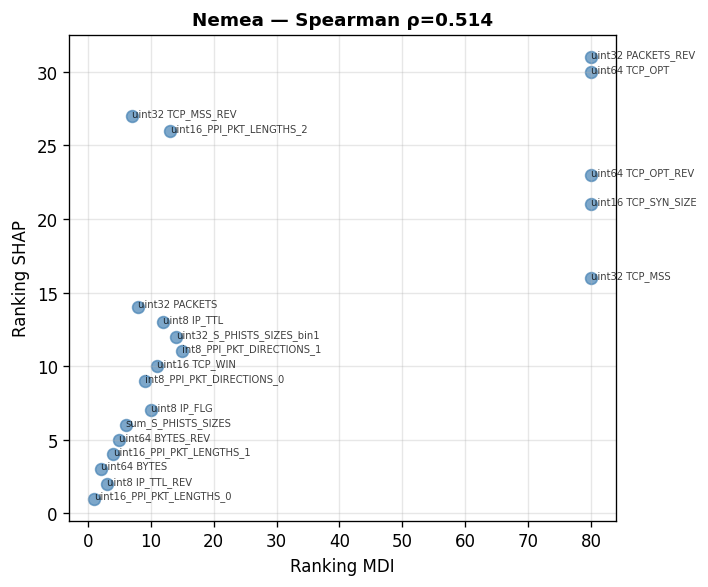


  [Tstat]
  Rank  Feature MDI                          Feature SHAP                       
  ----  -----------------------------------  -----------------------------------
     1  c_bytes_all                          c_bytes_all                          ✓
     2  s_bytes_all                          s_bytes_all                          ✓
     3  c_durat                              c_durat                              ✓
     4  c_pkts_all                           c_pkts_all                           ✓
     5  s_durat                              s_type                                
     6  c_rtt_min                            c_type                                
     7  c_rtt_avg                            s_pkts_all                            
     8  c_rtt_max                            s_durat                               
     9  s_pkts_all                           c_mss_min                             
    10  durat                                c_win_max                 

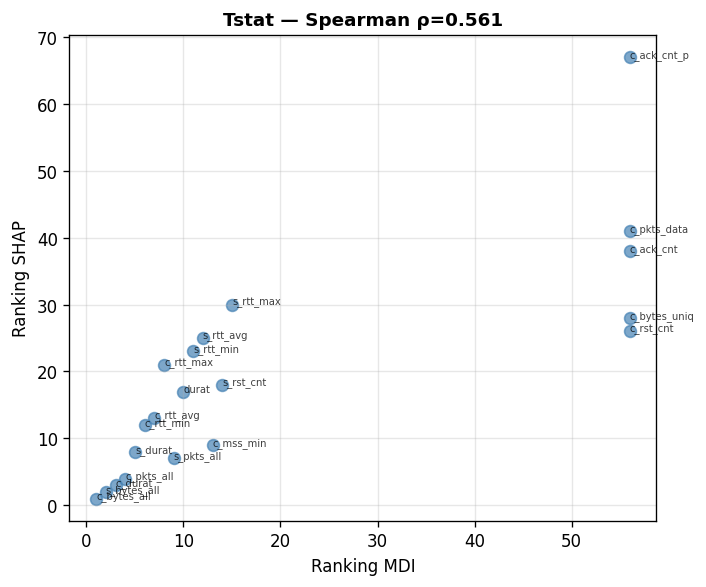


  [Tshark]
  Rank  Feature MDI                          Feature SHAP                       
  ----  -----------------------------------  -----------------------------------
     1  duration                             payload.min                           
     2  flow_duration_s                      payload.max                           
     3  int.max                              ip.ttl.std                            
     4  prate                                frame.len.max                         
     5  frame.len.max                        frame.len.min                         
     6  frame.len.mean                       payload.mean                          
     7  payload.max                          frame.len.mean                        
     8  int.std                              int.std                              ✓
     9  int.mean                             prate                                 
    10  frame.len.min                        int.max                  

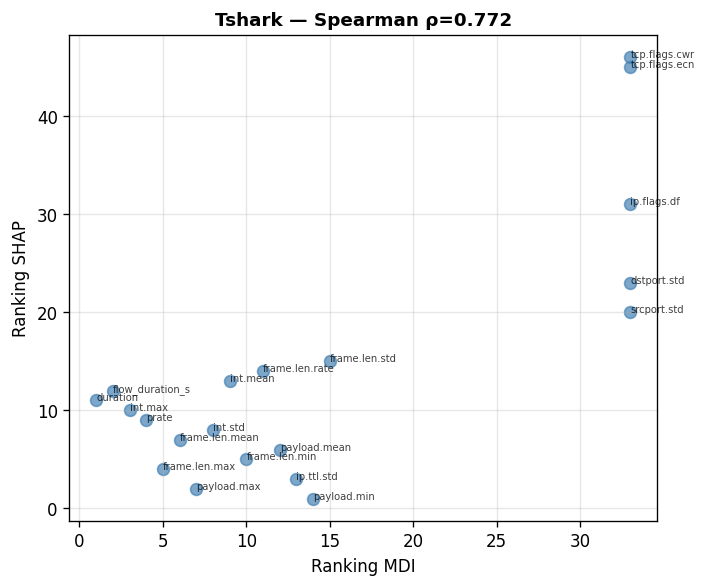


  RESUMEN GLOBAL (RF):
  Herramienta  Spearman ρ    Coincid. top-5   Coincid. top-10  Conclusión
  ----------  ------------  ---------------  ---------------  --------------------
  CIC                0.666  2/5             8/10            Parcialmente
  Nemea              0.514  5/5             8/10            Parcialmente
  Tstat              0.561  4/5             6/10            Parcialmente
  Tshark             0.772  1/5             7/10            Coinciden (ρ alto)


In [16]:
# ============================================================
# CELDA NUEVA C — COMPARACIÓN MDI vs SHAP (4 PDFs individuales)
# Tabla ranking lado a lado + scatter de correlación de Spearman
# ============================================================

import scipy.stats as stats

def comparar_mdi_vs_shap(resultados, nombre_modelo):
    print(f'\n{"="*65}')
    print(f'  COMPARACIÓN MDI vs SHAP — {nombre_modelo}')
    print(f'{"="*65}')

    for res in resultados:
        herramienta = res['herramienta']
        mdi_top     = res.get('mdi_top')
        shap_top    = res.get('shap_top')

        if mdi_top is None or shap_top is None or len(shap_top) == 0:
            print(f'[{herramienta}] Sin datos MDI o SHAP — saltando.')
            continue

        mdi_full  = mdi_top
        shap_full = shap_top

        print(f'\n  [{herramienta}]')
        print(f'  {"Rank":>4}  {"Feature MDI":35s}  {"Feature SHAP":35s}')
        print(f'  {"-"*4}  {"-"*35}  {"-"*35}')
        for i in range(min(10, len(mdi_full), len(shap_full))):
            feat_mdi  = mdi_full.index[i]  if i < len(mdi_full)  else ''
            feat_shap = shap_full.index[i] if i < len(shap_full) else ''
            marca = '✓' if feat_mdi == feat_shap else ' '
            print(f'  {i+1:>4}  {feat_mdi:35s}  {feat_shap:35s}  {marca}')

        mdi_set5   = set(mdi_full.index[:5])
        shap_set5  = set(shap_full.index[:5])
        mdi_set10  = set(mdi_full.index[:10])
        shap_set10 = set(shap_full.index[:10])
        print(f'  Coincidencia top-5:  {len(mdi_set5 & shap_set5)}/5 features')
        print(f'  Coincidencia top-10: {len(mdi_set10 & shap_set10)}/10 features')

        feature_names = res.get('feature_names', list(mdi_top.index))
        mdi_serie  = res['mdi_top'].reindex(feature_names).fillna(0)

        shap_values = res.get('shap_values_raw')
        X_shap      = res.get('X_shap_raw')

        if shap_values is not None:
            if isinstance(shap_values, list):
                shap_abs_mean = np.mean([np.abs(sv) for sv in shap_values], axis=0)
            elif shap_values.ndim == 3:
                shap_abs_mean = np.mean(np.abs(shap_values), axis=2)
            else:
                shap_abs_mean = np.abs(shap_values)
            shap_serie = pd.Series(shap_abs_mean.mean(axis=0), index=feature_names)
        else:
            shap_serie = shap_top.reindex(feature_names).fillna(0)

        rk_mdi  = mdi_serie.rank(ascending=False)
        rk_shap = shap_serie.rank(ascending=False)

        corr, pval = stats.spearmanr(rk_mdi, rk_shap)
        print(f'  Spearman MDI–SHAP:   ρ={corr:.3f}  (p={pval:.2e})')

        # ── Figura individual por herramienta ──────────────
        fig, ax = plt.subplots(figsize=(6, 5))
        top20 = mdi_serie.nlargest(20).index
        ax.scatter(rk_mdi[top20], rk_shap[top20], alpha=0.7, s=50, color='steelblue')
        for feat in top20:
            ax.annotate(feat, (rk_mdi[feat], rk_shap[feat]),
                        fontsize=6, alpha=0.75, ha='left')
        ax.set_xlabel('Ranking MDI', fontsize=10)
        ax.set_ylabel('Ranking SHAP', fontsize=10)
        ax.set_title(f'{herramienta} — Spearman ρ={corr:.3f}', fontsize=11, fontweight='bold')
        ax.grid(alpha=0.3)
        plt.tight_layout()
        if GUARDAR_FIGURAS:
            fig.savefig(RUTA_FIGURAS / f'MDI_vs_SHAP_scatter_{nombre_modelo}_{herramienta}.pdf', dpi=150)
        plt.show()
        plt.close()

    # ── Tabla global: ¿son ortogonales o coinciden? ──────────
    print(f'\n  RESUMEN GLOBAL ({nombre_modelo}):')
    print(f'  {"Herramienta":10s}  {"Spearman ρ":12s}  {"Coincid. top-5":15s}  {"Coincid. top-10":15s}  Conclusión')
    print(f'  {"-"*10}  {"-"*12}  {"-"*15}  {"-"*15}  {"-"*20}')

    for res in resultados:
        herramienta = res['herramienta']
        mdi_full  = res.get('mdi_top')
        shap_full = res.get('shap_top')
        if mdi_full is None or shap_full is None or len(shap_full) == 0:
            continue

        feature_names = res.get('feature_names', list(mdi_full.index))
        mdi_serie  = mdi_full.reindex(feature_names).fillna(0)

        shap_values = res.get('shap_values_raw')
        if shap_values is not None:
            if isinstance(shap_values, list):
                shap_abs_mean = np.mean([np.abs(sv) for sv in shap_values], axis=0)
            elif shap_values.ndim == 3:
                shap_abs_mean = np.mean(np.abs(shap_values), axis=2)
            else:
                shap_abs_mean = np.abs(shap_values)
            shap_serie = pd.Series(shap_abs_mean.mean(axis=0), index=feature_names)
        else:
            shap_serie = shap_full.reindex(feature_names).fillna(0)

        rk_mdi  = mdi_serie.rank(ascending=False)
        rk_shap = shap_serie.rank(ascending=False)
        corr, _ = stats.spearmanr(rk_mdi, rk_shap)

        c5  = len(set(mdi_full.index[:5])  & set(shap_full.index[:5]))
        c10 = len(set(mdi_full.index[:10]) & set(shap_full.index[:10]))

        if corr > 0.7:
            conclusion = 'Coinciden (ρ alto)'
        elif corr > 0.4:
            conclusion = 'Parcialmente'
        else:
            conclusion = 'Ortogonales'

        print(f'  {herramienta:10s}  {corr:12.3f}  {c5}/5{" ":11s}  {c10}/10{" ":10s}  {conclusion}')


# Cambia aquí el nombre según el notebook:
comparar_mdi_vs_shap(resultados_rf, 'RF')